In [1]:
# https://github.com/eclique/RISE/blob/master/explanations.py

from utils.cub_config import Config
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
from PIL import Image
from torchvision import models, transforms
import cv2 
from skimage.transform import resize
import matplotlib.pyplot as plt
import os
from utils.cub_config import Config

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model_path = Config.MODEL
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 200)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

Usando dispositivo: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [4]:
class RISE(nn.Module):
    def __init__(self, model, input_size, gpu_batch=10):
        super(RISE, self).__init__()
        self.model = model
        self.input_size = input_size
        self.gpu_batch = gpu_batch
    
    def generate_masks(self, N, s, p1, savepath='masks.npy'):
        from skimage.transform import resize
        
        cell_size = np.ceil(np.array(self.input_size) / s)
        up_size = (s + 1) * cell_size
        grid = np.random.rand(N, s, s) < p1
        grid = grid.astype('float32')
        self.masks = np.empty((N, *self.input_size))
        
        for i in tqdm(range(N), desc='Generating filters'):
            x = np.random.randint(0, cell_size[0])
            y = np.random.randint(0, cell_size[1])
            self.masks[i, :, :] = resize(grid[i], up_size, order=1, mode='reflect',
                                         anti_aliasing=False)[x:x + self.input_size[0], y:y + self.input_size[1]]
        
        self.masks = self.masks.reshape(-1, 1, *self.input_size)
        np.save(savepath, self.masks)
        self.N = N
        self.p1 = p1
    
    def load_masks(self, filepath):
        self.masks = np.load(filepath)
        self.N = self.masks.shape[0]
    
    def forward(self, x):
        N = self.N
        B, C, H, W = x.size()
        
        p_list = []
        
        for i in tqdm(range(0, N, self.gpu_batch), desc='Processing masks'):
            end_idx = min(i + self.gpu_batch, N)
            
            batch_masks = torch.from_numpy(self.masks[i:end_idx]).float().to(x.device)
 
            stack = torch.mul(batch_masks, x.data)

            with torch.no_grad():
                batch_p = self.model(stack)
                p_list.append(batch_p.cpu())  
            
            del batch_masks, stack
            torch.cuda.empty_cache()
        

        p = torch.cat(p_list).to(x.device)

        CL = p.size(1)
        
        sal = torch.zeros((CL, H * W), device=x.device)
        
        for i in range(0, N, self.gpu_batch):
            end_idx = min(i + self.gpu_batch, N)
            batch_masks = torch.from_numpy(self.masks[i:end_idx]).float().to(x.device)
            batch_p = p[i:end_idx]
            
            sal += torch.matmul(batch_p.data.transpose(0, 1), 
                               batch_masks.view(end_idx - i, H * W))
            
            del batch_masks
            torch.cuda.empty_cache()
        
        sal = sal.view((CL, H, W))
        sal = sal / N / self.p1
        
        return sal

In [5]:
input_size = (448, 448)
explainer = RISE(model, input_size, gpu_batch=100)

In [6]:
N = 3000  # Quanto maior, melhor a qualidade (mas mais lento)
s = 8     # Tamanho do grid
p1 = 0.5  # Probabilidade de manter cada célula

print("Gerando máscaras...")
explainer.generate_masks(N=N, s=s, p1=p1, savepath='../../model/masks.npy')

Gerando máscaras...


Generating filters: 100%|██████████| 3000/3000 [00:20<00:00, 148.07it/s]


In [7]:
image_path = "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg"
img = Image.open(image_path).convert('RGB')
input_tensor = transform(img).unsqueeze(0)

In [8]:
model = model.to(device)
input_tensor = input_tensor.to(device)

# Gerar saliency map
print("Gerando mapa de saliência...")
with torch.no_grad():
    sal = explainer(input_tensor)

# Obter a predição do modelo
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
confidence = torch.nn.functional.softmax(output, dim=1)[0, pred_class].item()

print(f"Classe predita: {pred_class}")
print(f"Confiança: {confidence:.4f}")

Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [04:26<00:00,  8.89s/it]


Classe predita: 26
Confiança: 0.1876


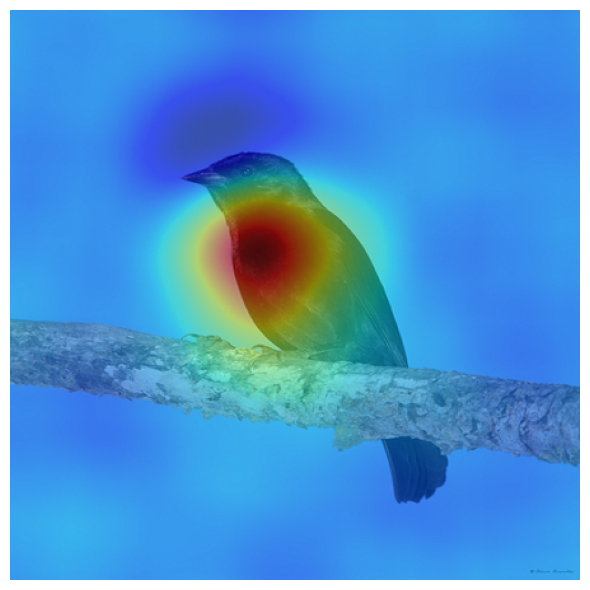

In [11]:
plt.figure(figsize=(6, 6))

# Imagem original
img_display = np.array(img)
sal_map = sal[pred_class].cpu().numpy()

raw_np = np.array(img.resize((448, 448))) / 255.0

# Overlay
plt.imshow(raw_np)
plt.imshow(sal_map, cmap='jet', alpha=0.5)
plt.axis('off')

plt.tight_layout()
img_name = os.path.basename(image_path)
path = os.path.join(Config.OUTPUT_DIR, f'rise_{img_name}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()